<a href="https://colab.research.google.com/github/sngillard/student-outcome-classification/blob/main/notebooks/02_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from statistics import linear_regression

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load processed data from CSV via GitHub link
df = pd.read_csv('https://raw.githubusercontent.com/sngillard/processed-student-success-prediction-data/refs/heads/main/student_data_processed_20260108csv.csv'
)

# View first 5 rows to verify data loaded right
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,-0.294829,0.210069,2.490896,-1.823744,0.350082,-0.386404,-0.145586,0.075111,-0.584526,-0.329669,...,-0.282442,-2.838337,-2.042630,-1.471527,-1.963489,-0.199441,-0.287638,0.124386,0.765761,0
1,-0.294829,-0.167406,-0.554068,0.254153,0.350082,-0.386404,-0.145586,-1.254495,-1.218380,-0.829997,...,-0.282442,-0.105726,-0.522682,0.518904,0.659562,-0.199441,0.876222,-1.105222,0.347199,2
2,-0.294829,-1.111094,2.490896,-1.131112,0.350082,-0.386404,-0.145586,1.072315,0.954834,0.670987,...,-0.282442,-0.105726,-2.042630,-1.471527,-1.963489,-0.199441,-0.287638,0.124386,0.765761,0
3,-0.294829,0.210069,0.207173,1.177663,0.350082,-0.386404,-0.145586,1.183116,0.954834,-0.329669,...,-0.282442,-0.105726,0.490616,0.187165,0.416450,-0.199441,-0.813253,-1.466871,-1.375511,2
4,1.356212,0.965018,-0.554068,-1.592866,-2.856470,-0.386404,-0.145586,1.072315,1.045384,0.670987,...,-0.282442,-0.105726,-0.522682,0.518904,0.531608,-0.199441,0.876222,-1.105222,0.347199,2


In [2]:
# Display column names (next to the column number which starts at index 0), data types (Dtype), and check for missing values (Non-Null Count) which there are none missing
df.info()

# Create a table that summarizes descriptive statistics for each numeric feature. Used for EDA (exploratory data analysis). .transpose() switches the columns and rows, so we can see the features listed in one column rather than the features being the columns.
df.describe().transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   float64
 1   Application mode                                4424 non-null   float64
 2   Application order                               4424 non-null   float64
 3   Course                                          4424 non-null   float64
 4   Daytime/evening attendance                      4424 non-null   float64
 5   Previous qualification                          4424 non-null   float64
 6   Nationality                                     4424 non-null   float64
 7   Mother's qualification                          4424 non-null   float64
 8   Father's qualification                          4424 non-null   float64
 9   Mother's occupation                      

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,9.636656e-18,1.000113,-0.294829,-0.294829,-0.294829,-0.294829,7.960376
Application mode,4424.0,-5.781993e-17,1.000113,-1.111094,-1.111094,0.210069,0.965018,2.097443
Application order,4424.0,-1.236704e-16,1.000113,-1.315309,-0.554068,-0.554068,0.207173,5.535860
Course,4424.0,-1.220643e-16,1.000113,-2.054621,-0.900234,0.023276,0.715908,1.639418
Daytime/evening attendance,4424.0,7.066881e-17,1.000113,-2.856470,0.350082,0.350082,0.350082,0.350082
Previous qualification,4424.0,-4.577411e-17,1.000113,-0.386404,-0.386404,-0.386404,-0.386404,3.650678
Nationality,4424.0,9.315434e-17,1.000113,-0.145586,-0.145586,-0.145586,-0.145586,11.294428
Mother's qualification,4424.0,-3.854662e-17,1.000113,-1.254495,-1.143694,0.075111,1.072315,1.847919
Father's qualification,4424.0,1.927331e-17,1.000113,-1.399481,-1.218380,-0.222324,0.954834,1.588688
Mother's occupation,4424.0,-2.409164e-17,1.000113,-1.580490,-0.579833,-0.329669,0.670987,6.174598


# EDA of Descriptive Statistics

### Above table is df.describe() which summarizes the descriptive statistics in a dataframe.

### .transpose() prints all numeric features as rows rather than columns so it's easier to compare values during exploratory data analysis (EDA).

### The descriptive statistics included in this table are as follows:

- **count**- # of non-null values. All features have 4424.0, so there are no missing values.

- **mean**- average value after scaling. Values are close to 0 bc data was standardized, so any values far from 0 would likely be skewed. ***Reminder:*** 9.6366563-18 is 0.0000000000000000096. So a zero, period, 17 zeros THEN 96.* ***VERY SMALL!!!!***

- **std** - standard deviation (spread of data). Shows how spread out values are. Should be around 1 bc StandardScaler was applied. Lower indicates less variability in values, while higher indicates more variability and potentially more predictive power.

- **min**- min value/the smallest standardized value. Helps visualize potential outliers. If a feature has a very low minimum, it may have extreme values.

- **25%**- Q1/25th percentile/first quartile. 25% of the data falls below this value. Helps understand shape of distribution and helps show if there's skewed values.

* **50%**- Q2/50th percentile/median. The middle value. If the median isn't equal to the mean, the feature may be skewed. Less affected by outliers (aka extreme values) and skewed data than the mean, so median/50% is a more useful value than the mean.

- **75%**- Q3/75th percentile/third quartile. Helps measure spread using IQR (inter-quartile range) which is Q3-Q1 = IQR.

- **max** - max value/the largest standardized value. Helps visualize potential outliers. If a feature has a very high max value, it may need to undergo transformations.

## Analyzing the descriptive statistics:
* StandardScaler() was applied to the processed data, so the values in the descriptive statistics table do not reflect the real-life values, rather the scaled values of the data after StandardScaler() applied z-score normalization to the values to get a mean closer to 0 and a std closer to 1 so that data is easier to work with.

### Mean:
- The mean values range from -0.000000000000000245737 to 1.178119.
- **Curricular units 2nd sem (grade)** has the *smallest mean*.
- **Target** has the *largest mean*.
- The five **smallest means** are: Curricular units 2nd sem (grade), Tuition fees up to date, Application order, Course, and Curricular units 2nd sem (evaluations).
- The five **largest means** are: Target, Curricular units 2nd sem (enrolled), Curricular units 1st sem (grade), Inflation rate, and Gender.
- *Because the dataset was standardized using StandardScaler(), the values do not represent their real-life values. A higher mean indicates that the feature's values tend to fall slightly higher than the standardized mean, which is zero. A lower mean indicates that the values tend to fall slightly below zero. Because StandardScaler() was used on the values in the processed dataframe, the means/averages are very small and close to 0.*

### Standard Deviation (STD):
- The std values range from 0.888243 to 1.000113.
- **Target** has the *smallest std*.
- **Curricular units 1st sem (grade)** has the *largest mean*.
- The five **smallest means** are: Target, Marital status, International, Application order, and Daytime/evening attendance.
- The five **largest means** are: Curricular units 1st sem (grade), Curricular units 2nd sem (evaluations), Unemployment rate, Nationality, and Father's qualification.
- *Because the dataset was standardized using StandardScaler(), the values do not represent their real-life values, and they are scaled to be close to 1.0. A higher std suggests that the values are far from the mean and a low std suggests that the values are grouped closer to the mean.*

### Minimum (min)
- The min values range from -2.856470 to 0.
- **Daytime/evening attendance** has the *largest min*.
- **Target** has the *largest min*.
- The five **smallest min values** are: Daytime/evening attendance, Curricular units 2nd sem (enrolled), Tuition fees up to date, Curricular units 1st sem (enrolled), and Curricular units 1st sem (grade)
- The five **largest min values** are: Target, Education special needs, Nationality, International, and Curricular units 1st sem (without evaluations).
- *A high min value suggests that all values for that feature are large. A low min value suggests that the feature has some very small, potentially negative, values.*

### 25% (Lower quartile/Q1)
- The Q1 values range from -1.218380to 0.368135.
- **Father's qualification** has the *smallest Q1 value*.
- **Tuition fees up to date** has the *largest Q1 value*.
- The five **smallest Q1 values** are: Father's qualification, Mother's qualification, Application mode, Displaced, and Course.
- The five **largest min values** are: Tuition fees up to date, Daytime/evening attendance, Curricular units 2nd sem (grade), Curricular units 1st sem (grade), and Target.
- *The higher and lower values in the 25% column reflect how high or low the values for that feature are in its lower quartile, meaning 25% of the data is less than or equal to the value shown in that column.*

### 50% (Median/Q2/50th percentile)
- The median values range from -0.736572 to 1.0.
- **Gender** has the *smallest median value*.
- **Target** has the *largest median value*.
- The five **smallest median values** are: Gender, Scholarship holder, Application order, Age at enrollment, and Previous qualification.
- The five **largest median values** are: Target, Displaced, Curricular units 2nd sem (grade), tuition fees up to date, and Daytime/evening attendance.  
- *The higher and lower values in the 50% (median) column reflect which features have higher and lower medians, meaning how high 50% of the data goes (as 50% of the values fall below the value in that column and the other 50% fall above that value.*

### 75% (Upper quartile/Q3)
- The Q3 values range from -0.574914to 2.0.
- **Scholarship holder** has the *smallest Q3 value*.
- **Target** has the *largest Q3 value*.
- The five **smallest Q3 values** are:  Scholarship holder, Previous qualification, Debtor, Curricular units 1st sem (credited), and Marital status.
- The five **largest median values** are: Target, Gender, Mother's qualification, Inflation rate, and Application mode.  
- *The features with higher values for 75% have larger values in 2/3 of their data, while the features with lower values for 75% have smaller values in 2/3 of their data.*

### Maximum (max)
- The max values range from 0.350082 to 17.171838.
- **Daytime/evening attendance** has the *smallest max value*.
- **Curricular units 1st sem (without evaluations)** has the *largest max value*.
- The five **smallest max values** are: Daytime/evening attendance, Tuition fees up to date, Displaced, Gender, and GDP.
- The five **largest max values** are: Curricular units 1st sem (without evaluations), Curricular units 2nd sem (without evaluations), Nationality, Curricular units 2nd sem (credited), and Educational special needs.
- *The higher max values suggest that those features have at least one large value and that outliers may be present, or that the feature just contains larger numerical values. Smaller max values suggest that those feature's values likely have a small range and do not reach larger values.*

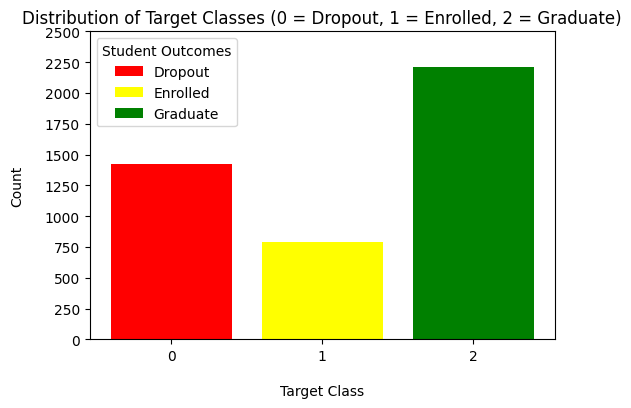

In [ ]:
# Create bar chart to visualize distribution of the target variable classes using Matplotlib
counts = df['Target'].value_counts().sort_index()
colors = ['red', 'yellow', 'green']

plt.figure(figsize=(6,4))

bars = plt.bar(counts.index, counts.values, color = colors)

# Add key
labels = ['Dropout', 'Enrolled', 'Graduate']
plt.legend(bars, labels, title="Student Outcomes")

plt.title("Distribution of Target Classes (0 = Dropout, 1 = Enrolled, 2 = Graduate)")
plt.xlabel("Target Class", labelpad = 15)
plt.ylabel("Count", labelpad = 15)

plt.xticks(counts.index)
plt.yticks(range(0, 2600, 250))

plt.show()


# EDA of Bar Chart- Interpretation of the Distribution of the Target Class
### The bar chart shows that the dataset is imbalanced across student outcomes.
* **Graduate (2)** is the largest group with close to 2,250 students.
* **Dropout (0)** is the second largest with around 1,400 students.
* **Enrolled (1)** is the smallest group with around 800 students.<br>When building the logistic regression and gradient boosting models in part B2, one needs to be aware that the model could become biased towards the Graduate (2) class because it is the majority class.

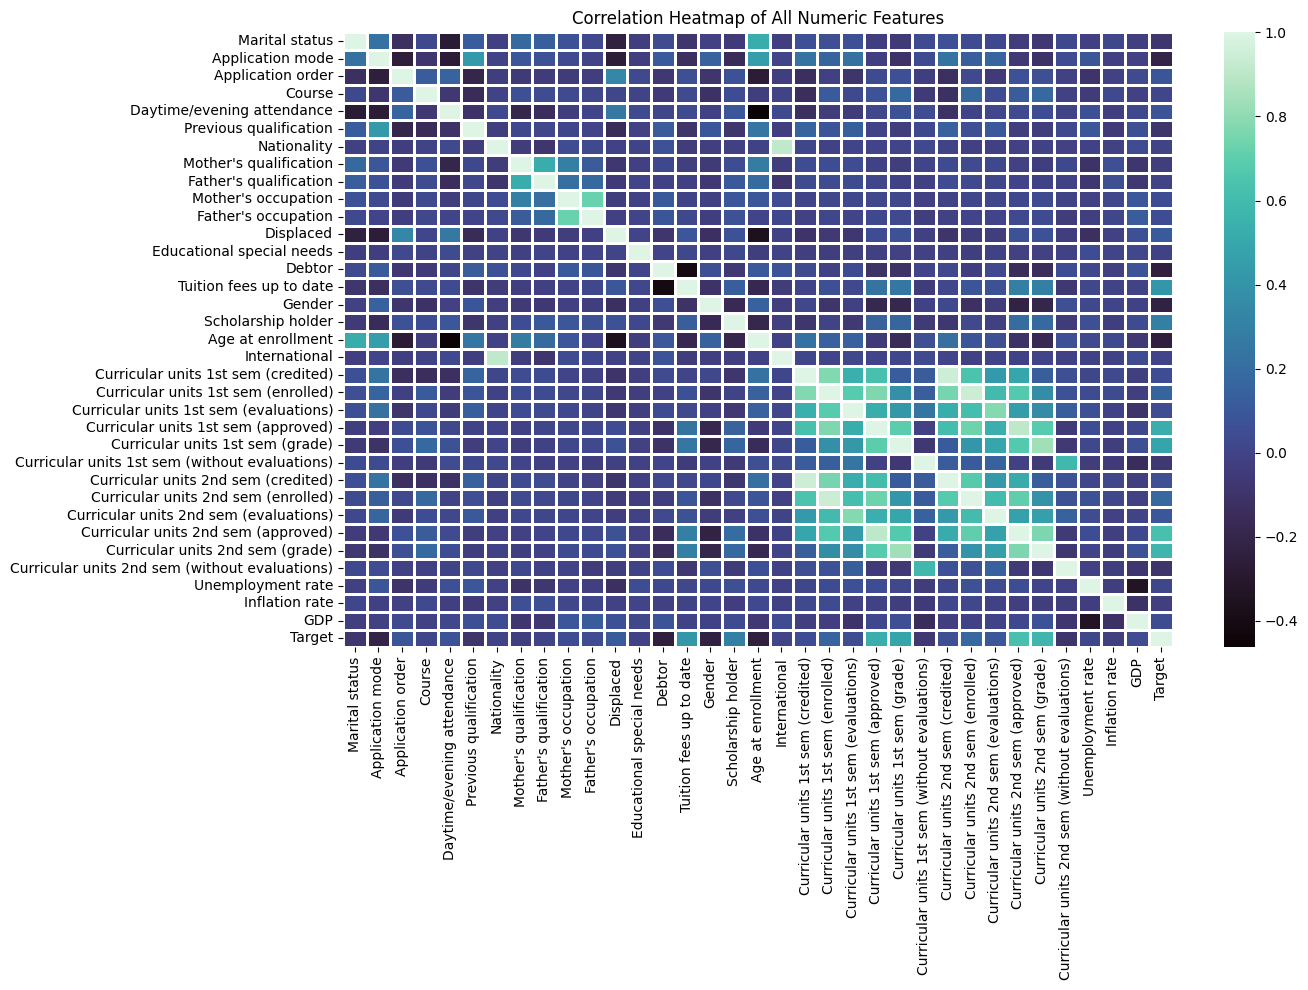

In [ ]:
# Create correlation heatmap for all 34 features (using seaborn)
plt.figure(figsize = (14,10))
sns.heatmap(df.corr(), cmap = "mako", linewidths = 1)
plt.title("Correlation Heatmap of All Numeric Features")
plt.tight_layout()

plt.show()

# EDA- Interpretation of the Correlation Heatmap for All Numeric Features
### This heatmap shows correlations between all numeric features.
Colors go from dark purple (around -0.4 indicating a weak or negative relationship between variables) to light teal (around 1.0 indicating a strong positive relationship between variables).
- The diagonal line is always equal to 1.0, which shows that each feature correlates precisely with itself.
- Some features show very strong correlations with each other (going both ways, meaning when each is on the x and y-axis they show the same correlations), such as:
    * Nationality and International: very light teal, around 0.9
    * Curricular units 1st sem (credited) and Curricular units 2nd sem (credited), Curricular units 1st sem (enrolled) and Curricular units 2nd sem (enrolled): very light teal, around 0.9
    * Curricular units 1st sem (approved) and Curricular units 2nd sem (grade): light teal, around 0.8
- Weak or negative correlations include (dark purple):
    * Age at enrollment and Daytime/evening attendance: very dark purple, around -0.4
    * Age at enrollment and Displaced: very dark purple, around -0.4
    * Tuition fees up to date and Debtor: very dark purple, around -0.4
- Most other correlations are near 0.0 (medium purple), meaning the features do not have strong influence on one another.
- The Curricular unit features for 1st and 2nd semesters have positive correlations with each other, with varying shades of blue and teal from about 0.1 to 0.9. These values are the cluster of blue and teal shades towards the bottom right quadrant of the heatmap.


In [ ]:
# Split the 34 feature variables into 3 categories: demographic features (6), socioeconomic factors (12), and academic performance features (16)

demographic_features = ['Marital status', 'Gender', 'Age at enrollment', 'Nationality', 'International', 'Daytime/evening attendance']

socioeconomic_features = ['Mother\'s qualification', 'Father\'s qualification', 'Mother\'s occupation', 'Father\'s occupation','Scholarship holder', 'Tuition fees up to date', 'Debtor', 'Displaced', 'Educational special needs', 'Unemployment rate', 'Inflation rate', 'GDP']

academic_performance_features = ['Application mode', 'Application order', 'Course', 'Previous qualification', 'Curricular units 1st sem (credited)' , 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)' , 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']

# Generate heat maps for the 3 feature categories (demographic, socioeconomic, and academic)

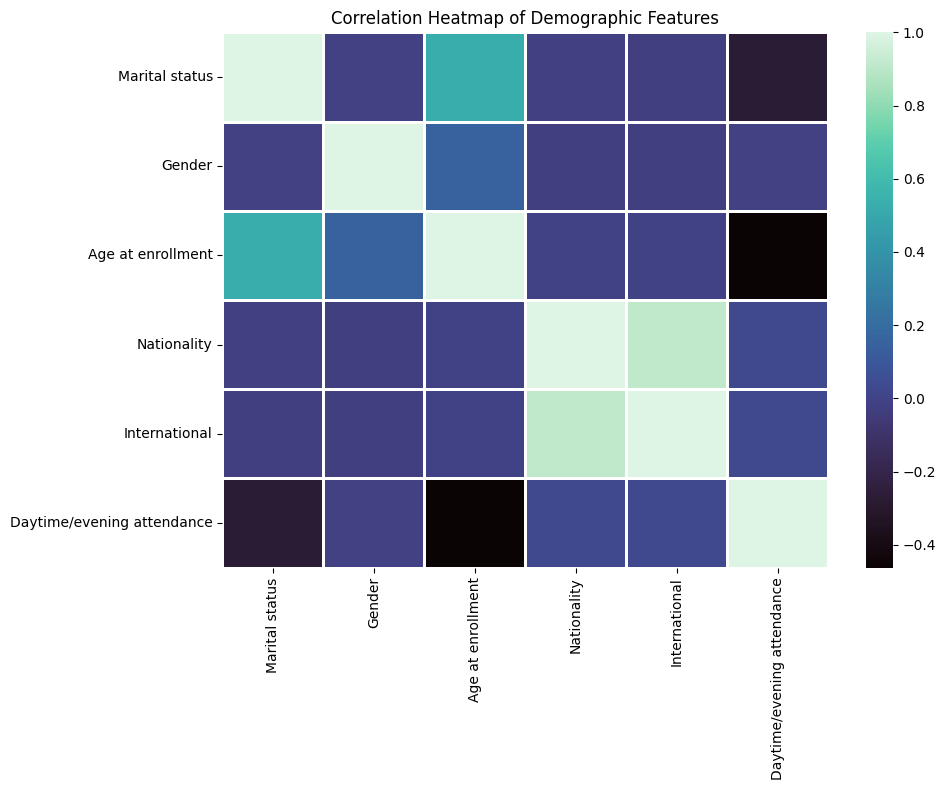

In [ ]:
# Heatmap for all six demographic features using seaborn
plt.figure(figsize = (10,8))
sns.heatmap(df[demographic_features].corr(), cmap = "mako", linewidths = 1)
plt.title("Correlation Heatmap of Demographic Features")
plt.tight_layout()

# EDA- Interpretation of the Correlation Heatmap for **Demographic** features
### This heatmap shows correlations between all **6 demographic features**.
Colors go from dark purple (around -0.4 indicating a weak or negative relationship between variables) to light teal (around 1.0 indicating a strong positive relationship between variables).
- The diagonal line is always equal to 1.0, which shows that each feature correlates precisely with itself.
- This heatmap has more variation in colors compared to the socioeconomic features heatmap, suggesting that demographic features have stronger relationships with one another than socioeconomic features do.
- Some of the stronger correlations in this heatmap include:
    * Age at enrollment and Marital status: medium teal, around 0.5
    * Nationality and International: light green, around 0.85
- Weaker or negative correlations in this heatmap include:
    * Age at enrollment and Daytime/evening attendance: very dark purple, around -0.4
    * Marital status and Daytime/evening attendance: dark purple, around -0.1
    * Gender and Age at enrollment: medium blue, around 0.2
- Most other correlations in this heatmap around medium purple, or around 0.0, meaning these demographic features do not strongly impact one another.


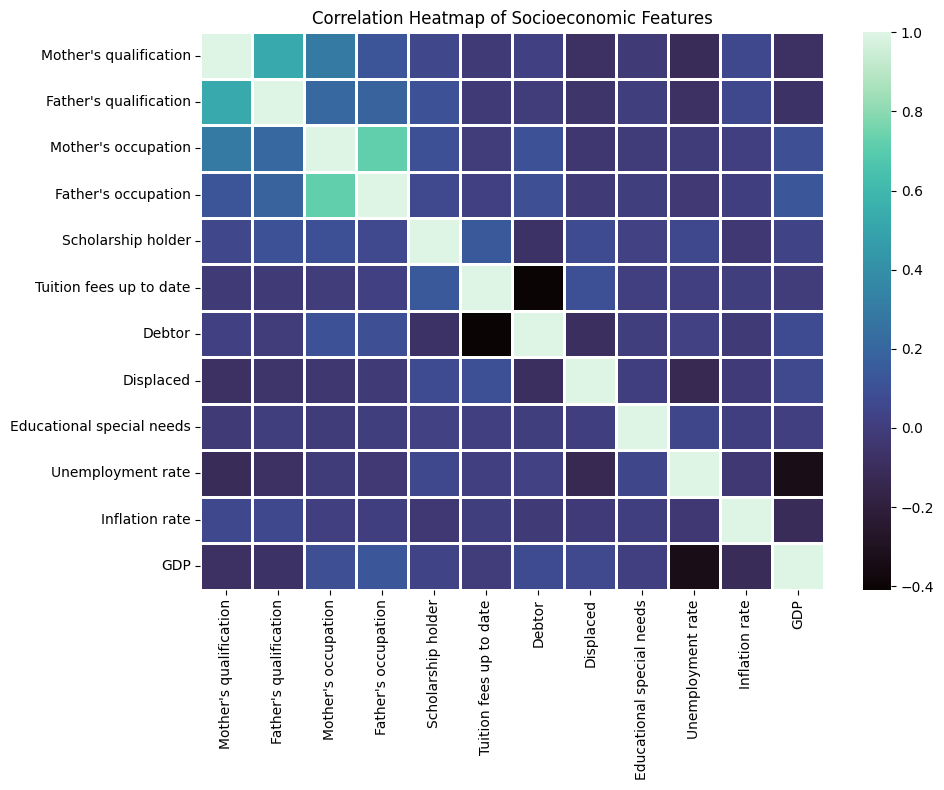

In [ ]:
# Heatmap for all twelve socioeconomic features using seaborn
plt.figure(figsize = (10,8))
sns.heatmap(df[socioeconomic_features].corr(), cmap = "mako", linewidths = 1)
plt.title("Correlation Heatmap of Socioeconomic Features")
plt.tight_layout()


# EDA- Interpretation of the Correlation Heatmap for **Socioeconomic** features
### This heatmap shows correlations between all **12 socioeconomic features**.
Colors go from dark purple (around -0.4 indicating a weak or negative relationship between variables) to light teal (around 1.0 indicating a strong positive relationship between variables).
- The diagonal line is always equal to 1.0, which shows that each feature correlates precisely with itself.
- Most correlations are various shades of purple, ranging from about -0.4 to 0.5. This suggests most socioeconomic features have weak or no correlation with other socioeconomic features.
- Some positive correlations include:
    * Mother's occupation and Father's occupation: brighter medium teal, around 0.7
    * Mother's qualification and Father's qualification: medium teal, around 0.5
    * Mother's occupation and Mother's qualification: medium blue, around 0.4
    * Father's occupation and Father's qualification: slightly darker medium blue, around 0.3
- GDP and Unemployment rate, as well as Tuition fees up to date and Debtor are both very dark purple, around -0.4, indicating very weak relationships between the GDP and Unemployment rate, as well as between the Tuition fees up to date and Debtor.

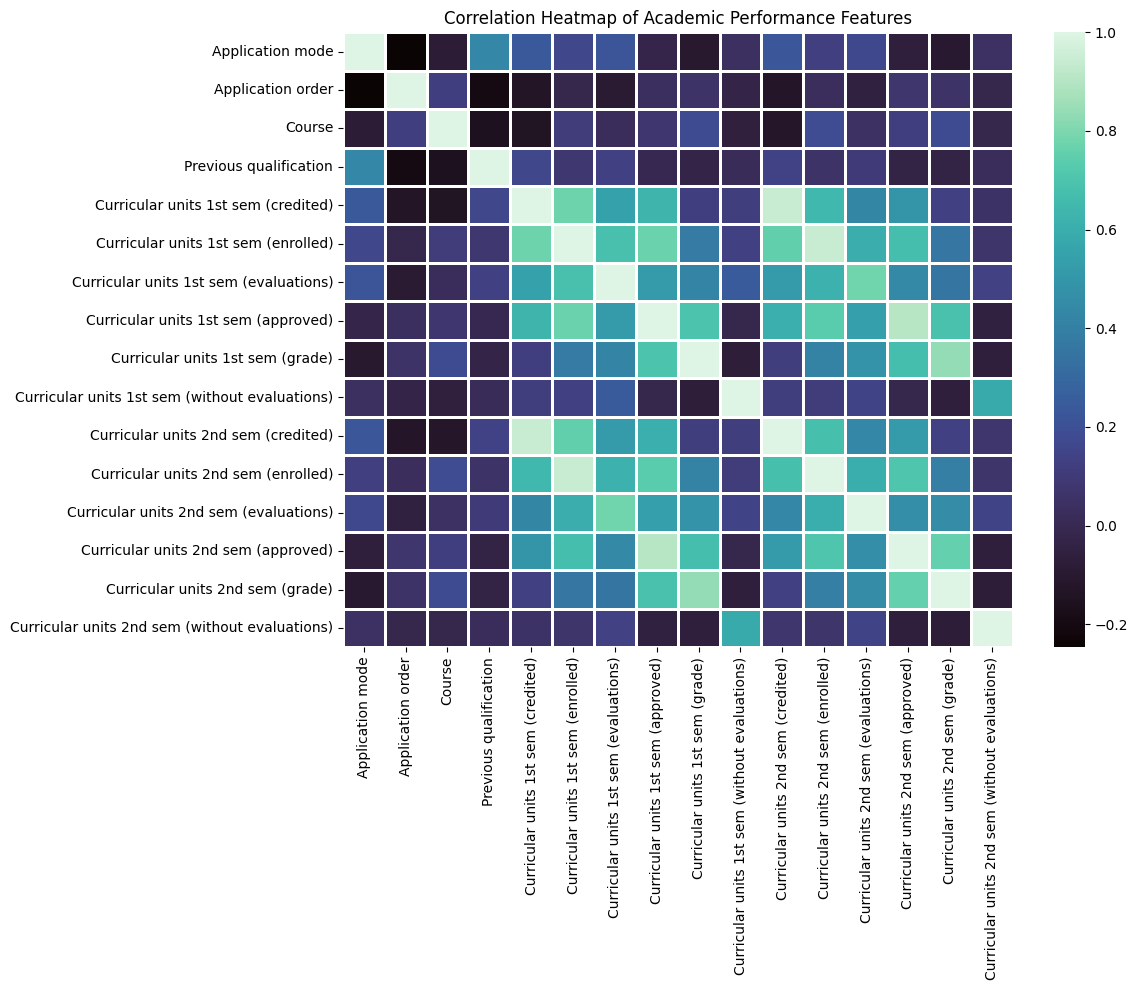

In [ ]:
# Heatmap for all sixteen academic performance features using seaborn
plt.figure(figsize = (12, 10))
sns.heatmap(df[academic_performance_features].corr(), cmap = "mako", linewidths = 1)
plt.title("Correlation Heatmap of Academic Performance Features")
plt.tight_layout()

# EDA- Interpretation of the Correlation Heatmap for **Academic Performance** features
### This heatmap shows correlations between all **16 academic performance features**.
 Colors go from dark purple (around -0.4 indicating a weak or negative relationship between variables) to light teal (around 1.0 indicating a strong positive relationship between variables).
- The diagonal line is always equal to 1.0, which shows that each feature correlates precisely with itself.
- This heatmap shows clusters of various shades of blue and teal as seen in the All Numerica Features Heatmap. These clusters are for correlations between Curricular unit features for the 1st and 2nd semesters for those units that are credited, enrolled, evaluated, approved, graded, and without evaluations. These correlations make sense as academic performance during the 1st semester should naturally affect performance in the 2nd semester.
- The clustered area shows a strong correlations between the curricular unit features, with most values showing as colors ranging from light teal/green to medium blue, with values ranging from 0.5 to 0.95.
- Application related features show weaker correlations, such as the following:
    * Application mode and Previous qualification: medium blue, around 0.3
    * Application mode and Application order: very dark purple, around -0.4
    * Application order and Previous qualification: very dark purple, around -0.4

In [ ]:
# Create correlation table for 3 feature variable categories (demographic, socioeconomic, academic) in correlation with target variable (drop out, enrolled, graduate)

corr = df.corr(numeric_only=True)

# Find averages for each category
demographic_corr = corr.loc[demographic_features, 'Target'].abs().mean()
socioeconomic_corr = corr.loc[socioeconomic_features, 'Target'].abs().mean()
academic_corr = corr.loc[academic_performance_features, 'Target'].abs().mean()

# Create final summary with category averages for category correlation data frame
category_target_correlation_df = pd.DataFrame({
    'Category': ['Demographic', 'Socioeconomic', 'Academic Performance'],
    'Average Correlation with Target Variable': [
        demographic_corr, socioeconomic_corr, academic_corr
    ]
})

category_target_correlation_df



,Category,Average Correlation with Target Variable
0,Demographic,0.107715
1,Socioeconomic,0.107350
2,Academic Performance,0.208758


# EDA- Interpretation of Table for Correlations between Feature Categories and the Target Variable
* Looking at the above table, we see that **academic performance** features show the strongest relationship with the target variable with an average correlation value of **0.208758**. This suggests that a student's academic behaviors have a greater impact on predicting whether they graduated, remain enrolled, or drop out.
* **Socioeconomic** and **demographic** features have similar correlation values with the target variable. Their values suggest a weaker effect on predicting whether a student graduates, remains enrolled, or drops out. The **demographic features** have a *slightly* higher correlation of **0.107715** compared to the correlation value of **0.107350** for the **socioeconomic** features.
* None of the correlation values are close to 1.0, so the three categories of combined feature variables show weak correlation with the target variable, but academic performance features averaged has the greatest impact on the target variable compared to demographic and socioeconomic features.

In [ ]:
corr = df.corr(numeric_only=True)

demographic_features = ['Marital status', 'Gender', 'Age at enrollment', 'Nationality', 'International', 'Daytime/evening attendance']

socioeconomic_features = ['Mother\'s qualification', 'Father\'s qualification', 'Mother\'s occupation', 'Father\'s occupation','Scholarship holder', 'Tuition fees up to date', 'Debtor', 'Displaced', 'Educational special needs', 'Unemployment rate', 'Inflation rate', 'GDP']

academic_performance_features = ['Application mode', 'Application order', 'Course', 'Previous qualification', 'Curricular units 1st sem (credited)' , 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)' , 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']

target_variable = ['Target']

# Combine 3 feature categories and target into one list
all_feature_categories_list = demographic_features + socioeconomic_features + academic_performance_features + target_variable

# Create a full correlation matrix (all features)
full_correlation_matrix = df[all_feature_categories_list].corr().round(2)

# Only select Target variable column
target_correlations_only_matrix = full_correlation_matrix['Target']

# Only print the Target column
print('\nIndividual Feature Correlations with Target Variable (ascending order):')

# Arrange table so correlations are in ascending order
sorted_correlation_table = target_correlations_only_matrix.sort_values(ascending=True)

# Print the sorted table
print(sorted_correlation_table)



Individual Feature Correlations with Target Variable (ascending order):
Age at enrollment                                -0.24
Debtor                                           -0.24
Gender                                           -0.23
Application mode                                 -0.21
Previous qualification                           -0.09
Marital status                                   -0.09
Curricular units 2nd sem (without evaluations)   -0.09
Curricular units 1st sem (without evaluations)   -0.07
Mother's qualification                           -0.04
Inflation rate                                   -0.03
Educational special needs                        -0.01
Nationality                                      -0.00
Father's qualification                            0.00
International                                     0.00
Course                                            0.01
Unemployment rate                                 0.01
Curricular units 1st sem (evaluations)         

# EDA- Interpretation of Table for Correlations between all Features and the Target Variable
* The values range from -0.24 to 1.0.
* 1.0 indicates perfect correlation and is shown in the table when the Target variable is correlated with itself, which should happen.
* Most values are small because the data was standardized using StandardScaler().
* The small values suggest that most features do not have a strong effect on the target variable alone.
* The features with the **smallest** or **weakest** correlation with the target variable are:
    - Age at enrollment and Debtor (both are -0.24)
    - Gender (-0.23)
    - Application mode (-0.21)
    - Previous qualification, Martial status, and Curricular units 2nd sem (without evaluations) (all are -0.09)
    * Curricular units 1st sem (without evaluations) (-0.07)
* The features with the **most positive** or **strongest** correlation with the target variable are:
    * Curricular units 2nd sem (approved) (0.62)
    * Curricular units 2nd sem (grade) (0.57)
    * Curricular units 1st sem (approved) (0.53)
    * Curricular unist 1st sem (grade) (0.49)
    * Tuition fees up to date (0.41)
    * Scholarship holder (0.30)

However, none of these features are *that close to 1.0*, so it appears none have a huge impact on the target variable, but **academic performance features** appear to have the greatest effect in this correlation table just as they do in the above *feature category correlation table* and as they do in the clustered area of blues and teals in the *heatmap for all numeric  features*.  

In [ ]:
from sklearn.model_selection import train_test_split

# Top features from correlation table (strong relationship with target, not including Curricular units 2nd sem (approved) as that is what is predicted in this model (can't predict the target as it's an encoded string)
top_features_for_prediction = [
    'Curricular units 1st sem (approved)',
    'Tuition fees up to date',
    'Scholarship holder',
    'Curricular units 1st sem (enrolled)',
    'Displaced',
    'Debtor',
    'Daytime/evening attendance',
    'Age at enrollment',
    'Gender',
    'Marital status',
    'Previous qualification',
    'Educational special needs',
    'Nationality',
    'International',
    'Course',
    'Unemployment rate',
    'GDP',
    'Inflation rate'
]

# Predict a numeric outcome (the target variable). Using Curricular units 1st sem (grade) because it was one of the features with a strong correlation to the encoded target variable, but can't use the encoded or string for that target variable in a regression model. However, the feature with the strongest correlation to the target variable is Curricular units for 2nd sem (approved) and (grade), which makes sense because if you are or aren't enrolled after the first semester, then your status for 2nd sem features may or may not exist.
y = df['Curricular units 1st sem (grade)']

# Use only features that would likely have a greater impact on 1st semester grades (so not 2nd semester features of any kind, not parent related features)
X = df[top_features_for_prediction]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state =42
)

# Build the linear regression model for EDA
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

# Predictions
y_predictions = linear_regression.predict(X_test)

# Test and validate with regression evaluations metrics (MAE, MSE, and R2)
mae = mean_absolute_error(y_test, y_predictions)
mse = mean_squared_error(y_test, y_predictions)
r2 = r2_score(y_test, y_predictions)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'R-squared: {r2}')



MAE: 0.511379123812683
MSE: 0.4583764404703931
R-squared: 0.5377866519045464


# EDA- Linear Regression Evaluation Metrics
## Mean Absolute Error (MAE)
* MAE = 0.51, reflecting that on average, the model's predictions for 1st semester grades are off by about 0.51 units. Since the data was normalized using StandardScaler(), this means an MAE of 1.0 would indicate perfectly correct predictive power in the model. *So, a score of 0.51 here suggests that the predictive power is moderate.*
* This helps with EDA for the target variable we will be predicting in the final models because 1st semester grade was a feature variable that had a strong correlation to the target variable when compared to the other features (but omitting 2nd semester curricular data).
* **This score tells us that the average error is about half a standard deviation of the target.**

## Mean Squared Error (MSE)
* MSE = 0.46, indicating moderate predictive ability in the model. 0.46 MSE also indicates that some larger prediction errors are present in the model, but they aren't extreme and there aren't too many (also reflected in the residual plot below).
* MSE is like MAE with a penalty because it squares the values, so larger errors are squared and look greater

## R-squared (R2 score)
* R2 = 0.54, which means about 54% of the variance in 1st semester grades is explained by the selected features.
* This score suggests there is some explainability on feature impact on the target variable. A score of 0.0 tells us the model doesn't explain any variance, and a score of 1.0 means variance is perfectly explained by the model. So, *a score of 0.54 shows moderate explainability* between the selected features and 1st semester grade (a key variable for predicting the target variable in the categorical models). This makes sense because the EDA multiple linear regression model uses various demographic, enrollment, and financial variables which would likely impact one's success in the first semester.
* **The R2 score of 0.54 tells us that about 54% of the target variable for EDA's variance is explained by the model.**

In [ ]:
# Create table for correlation of selected feature variables with 1st semester grade (EDA)
correlation_table = (
    df[top_features_for_prediction + ['Curricular units 1st sem (grade)']]
    .corr()['Curricular units 1st sem (grade)']
    .sort_values(ascending=False)
)

correlation_df = correlation_table.reset_index()
correlation_df.columns = ['Feature', 'Correlation with 1st Semester Grade']
correlation_df


,Feature,Correlation with 1st Semester Grade
0,Curricular units 1st sem (grade),1.000000
1,Curricular units 1st sem (approved),0.696113
2,Curricular units 1st sem (enrolled),0.376996
3,Tuition fees up to date,0.250394
4,Course,0.179482
5,Scholarship holder,0.168324
6,Displaced,0.064815
7,Daytime/evening attendance,0.063974
8,GDP,0.054801
9,Unemployment rate,0.014821


# EDA- Correlation Table for Relationship with 1st Semester Grade
### The table above shows the correlation coefficients between the selected features and the first semester grade.
* Values close to **0** indicate very weak or no linear relationship of the feature variable on the 1st semester grade, such as Nationality and International status.
* Values between 0 and 1 tell us that as the feature variable value increases, the target variable also increases (a positive relationship between them). Approved and enrolled curricular units in the first semester have the strongest correlation value with the 1st semester grade, with correlation values of 0.7 0.38, and 0.25. So, approved and enrolled first semester curricular units increase as students' grade increases. This makes sense, as a grade would indicate that the student's first semester grades were already enrolled and approved.
* Tuition feeds up to date, Course, and Scholarship holder have the next strongest correlations, which values randing from 0.168 to 0.2504.
* Negative values tells us that the target variable value decreases as the feature variable increases, so there is a negative relationship between the feature and target.
* **The multiple linear regression model (used for EDA only) shows that the model is not perfect at predicting first semester grades, which have a greater impact on enrollment status. However, this does not mean the next models will have weak predictive power as they are categorical models that will predict the enrollment status represented by encoded numbers 0-2.
* *This model is only used for data analysis.*

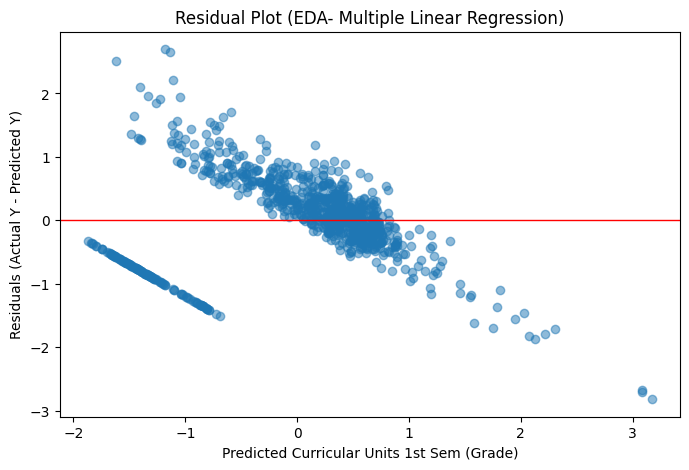

In [ ]:
# Residual plot to show how well the model predicts the first semester grade(which has a strong correlation with the Target variable, comparatively)
plt.figure(figsize=(8, 5))
plt.scatter(y_predictions, y_test - y_predictions, alpha = 0.5)
plt.xlabel('Predicted Curricular Units 1st Sem (Grade)')
plt.ylabel('Residuals (Actual Y - Predicted Y)')
plt.title('Residual Plot (EDA- Multiple Linear Regression)')
plt.axhline(y=0, color='red', linewidth=1)

plt.show()

# EDA- Residual Plot Interpretation
* A residual is the difference between the **actual grade** and the grade the model **predicts**.
* The majority of residuals cluster around zero, which tells us that the model is mostly predicting grades that are close to the actual values.
* The dots are spread vertically with a negative slope, which indicates that the model has some large errors in predictions and is not capturing everything that influences the first semester grade.
* The plot shows that the model tends to produce greater error/residuals for students with very high or very low grades, and is more accurate at predicting grades for average students.